<a href="https://colab.research.google.com/github/Qunzh/CAN_GridCell_Model/blob/main/Ring_Model_V1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import torch

In [ ]:
#Ring Model

def ring_model(epsilon, theta_cue, A, c, n_number, tau, J_0, J_2, dt, total_t, theta_0, a):
# Parameters for thalamic(LGN) input: epsilon = tuning, theta_cue = peak preferred orientation, c = contrast, A = amplitude
# Parameters for V1: n_number = total number of neurons, tau = time constant, J_0 = recurrent inhibition weight, J_2 = recurrent excitation weight
# Parameters for time: dt = length of timestep, total_t = total integration time
# Parameters for initial conditions: theta_0 = initial tuned orientation of V1, a = initial rate amplitude of V1

  # Initialization
  t_steps = int(total_t/dt)
  rate = np.zeros((t_steps, n_number))
  I_theta = np.zeros((t_steps, n_number))  # Store for verification
  recurrent = np.zeros((t_steps, n_number))  # Store for verification
  h_theta = np.zeros((n_number))

  # Neuron Label
  theta_i = np.zeros((n_number))
  for i in range(0, n_number):
    theta_i[i] = (np.pi/n_number) * i - np.pi/2

  # Intial Conditions
  for i in range(0, n_number):
    rate[0, i] = a * np.cos(2 * (theta_i[i] - theta_0))

  # Thalamic input
  for i in range(0, n_number):
    h_theta[i] = A * c * (1 - epsilon + epsilon * np.cos(2 * (theta_i[i] - theta_cue)))

  # Pre-compute connectivity matrix
  theta_diff = theta_i[:, np.newaxis] - theta_i[np.newaxis, :]
  W = (J_0 + J_2 * np.cos(2 * theta_diff)) * (np.pi / n_number)

  # Time integration
  for t in range(1, t_steps):
    # Vectorized recurrent calculation
    recurrent[t, :] = W @ rate[t-1, :]

    # Total input
    I_theta[t, :] = h_theta + recurrent[t, :]

    # Rectification
    I_theta[t, :] = np.maximum(I_theta[t, :], 0)

    # Euler integration
    drdt = (-rate[t-1, :] + I_theta[t-1, :]) / tau
    rate[t, :] = rate[t-1, :] + drdt * dt

  steady_state = rate[t, :]
  return theta_i, steady_state

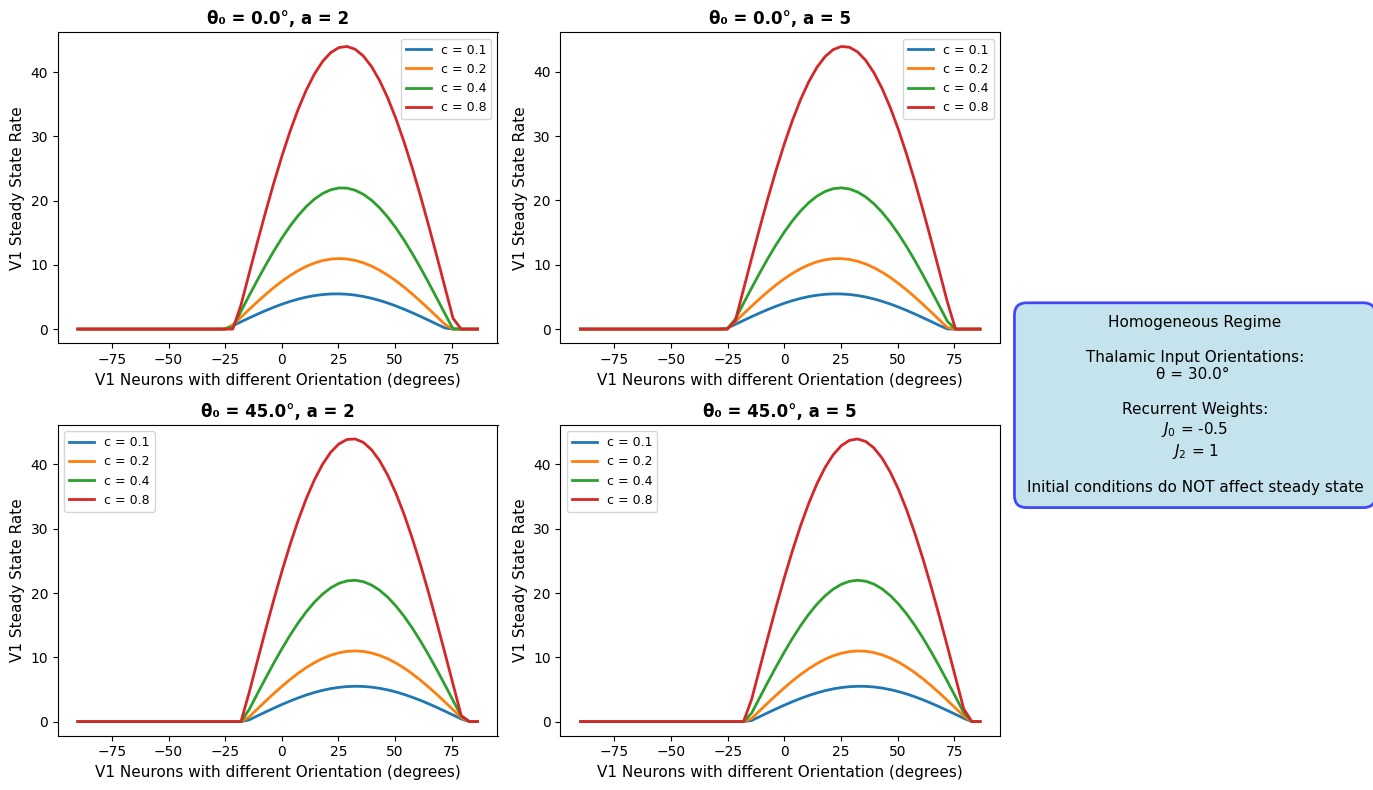

In [ ]:
# Homogeneous regime (with small recurrent excitation J_2 and small recurrent inhibition J_0)
J_0, J_2 = -0.5, 1
theta_cue = np.pi/6
contrast_values = [0.1, 0.2, 0.4, 0.8]
theta_0_values = [0, np.pi/4]
a_values = [2, 5]

fig, axes = plt.subplots(2, 2, figsize=(12, 8))

for idx, theta_0 in enumerate(theta_0_values):
    for idx_1, a in enumerate(a_values):
        ax = axes[idx, idx_1]

        for c in contrast_values:
            theta_i, steady_state = ring_model(0.1, theta_cue, 40, c, 50, 10, J_0, J_2, 0.01, 200, theta_0, a)
            ax.plot(np.rad2deg(theta_i), steady_state, label=f'c = {c}', linewidth=2)

        ax.set_xlabel('V1 Neurons with different Orientation (degrees)', fontsize=11)
        ax.set_ylabel('V1 Steady State Rate', fontsize=11)
        ax.set_title(f'θ₀ = {np.rad2deg(theta_0):.1f}°, a = {a}', fontsize=12, fontweight='bold')
        ax.legend(fontsize=9)

textstr = f'Homogeneous Regime\n \n Thalamic Input Orientations: \nθ = {np.rad2deg(theta_cue):.1f}° \n \nRecurrent Weights:\n$J_0$ = {J_0}\n$J_2$ = {J_2}\n\nInitial conditions do NOT affect steady state'
props = dict(boxstyle='round,pad=0.8', facecolor='lightblue', alpha=0.7, edgecolor='blue', linewidth=2)

fig.text(1, 0.6, textstr, transform=fig.transFigure, fontsize=11,
         verticalalignment='top', horizontalalignment='center', bbox=props)

plt.tight_layout(rect=[0, 0, 0.85, 1])
plt.show()

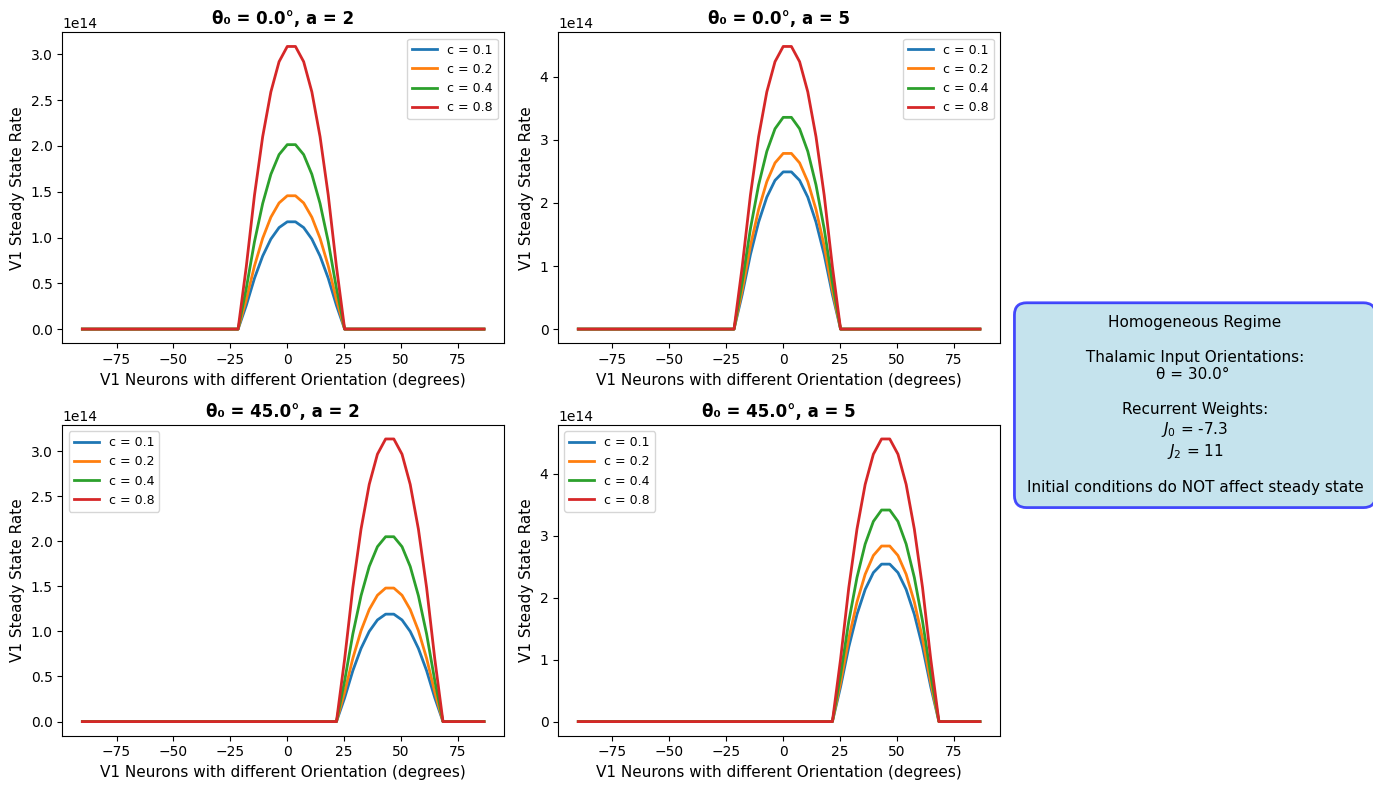

In [ ]:
# Amplitude Instability regime (with huge recurrent excitation J_2 and huge recurrent inhibition J_0)
J_0, J_2 = -7.3, 11
theta_cue = np.pi/6
contrast_values = [0.1, 0.2, 0.4, 0.8]
theta_0_values = [0, np.pi/4]
a_values = [2, 5]

fig, axes = plt.subplots(2, 2, figsize=(12, 8))

for idx, theta_0 in enumerate(theta_0_values):
    for idx_1, a in enumerate(a_values):
        ax = axes[idx, idx_1]

        for c in contrast_values:
            theta_i, steady_state = ring_model(0.1, theta_cue, 40, c, 50, 10, J_0, J_2, 0.01, 500, theta_0, a)
            ax.plot(np.rad2deg(theta_i), steady_state, label=f'c = {c}', linewidth=2)

        ax.set_xlabel('V1 Neurons with different Orientation (degrees)', fontsize=11)
        ax.set_ylabel('V1 Steady State Rate', fontsize=11)
        ax.set_title(f'θ₀ = {np.rad2deg(theta_0):.1f}°, a = {a}', fontsize=12, fontweight='bold')
        ax.legend(fontsize=9)

textstr = f'Homogeneous Regime\n \n Thalamic Input Orientations: \nθ = {np.rad2deg(theta_cue):.1f}° \n \nRecurrent Weights:\n$J_0$ = {J_0}\n$J_2$ = {J_2}\n\nInitial conditions do NOT affect steady state'
props = dict(boxstyle='round,pad=0.8', facecolor='lightblue', alpha=0.7, edgecolor='blue', linewidth=2)

fig.text(1, 0.6, textstr, transform=fig.transFigure, fontsize=11,
         verticalalignment='top', horizontalalignment='center', bbox=props)

plt.tight_layout(rect=[0, 0, 0.85, 1])
plt.show()